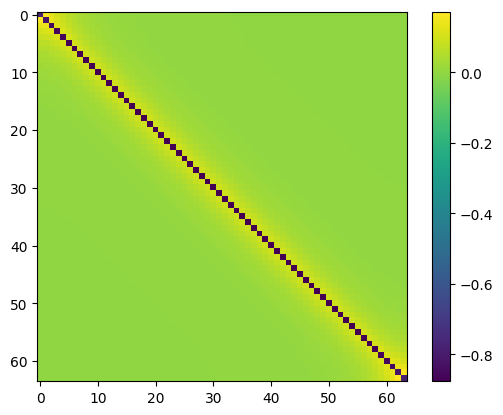

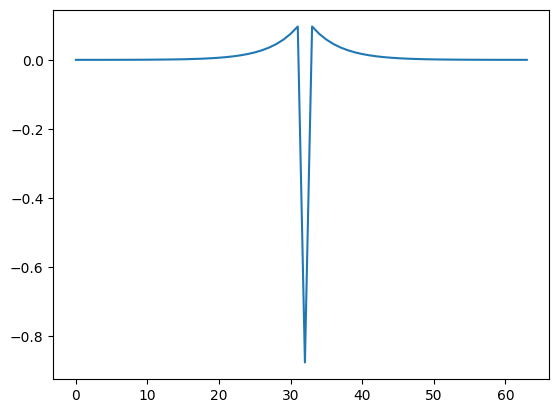

In [42]:
import numpy as np
import matplotlib.pyplot as plt

N = 64
velocity_kernel = np.zeros((N - 1, N))
velocity_kernel[:, 1:] = np.eye(N - 1)
velocity_kernel -= np.eye(N - 1, N)
K = velocity_kernel.T @ velocity_kernel
sigma = 4

score_kernel = -np.linalg.inv(K + np.eye(N) / (sigma ** 2)) @ K
plt.imshow(score_kernel)
plt.colorbar()
plt.show()

plt.plot(score_kernel[N // 2])
plt.show()


## Approach 1 for computing obstacle-based energy landscape

Here, I try direct integration. However, I don't think this approach is very feasible.

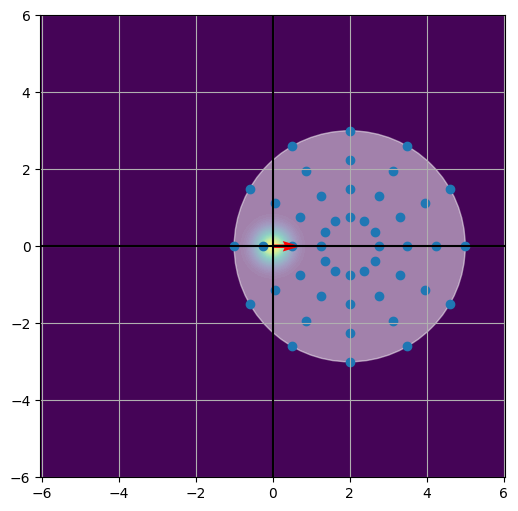

In [ ]:
import matplotlib.patches as patches

c_x = 2
R: float = 3

plt.figure(figsize=(6, 6))
plt.axis("equal")

# Color according to Gaussian.
gaussian_xx, gaussian_yy = np.meshgrid(
    np.linspace(-6, 6, 128),
    np.linspace(-6, 6, 128),
)
sigma = 0.3
gaussian_probability = (
    1
    / (2 * np.pi * sigma**2)
    * np.exp(-0.5 * (gaussian_xx**2 + gaussian_yy**2) / sigma**2)
)
plt.contourf(gaussian_xx, gaussian_yy, gaussian_probability, levels=50)
# plt.xlim(-6, 6)
plt.ylim(-6, 6)

plt.gca().axvline(x=0, color="k")
plt.gca().axhline(y=0, color="k")
plt.grid()
plt.gca().add_patch(patches.Circle((c_x, 0), R, fill=True, color="white", alpha=0.5))

N_segments = 12
angles = np.linspace(0, 2 * np.pi, N_segments, endpoint=False)
x = R * np.column_stack([np.cos(angles), np.sin(angles)])
evaluation_locations = np.concatenate([x, x * 0.75, x * 0.5, x * 0.25])
evaluation_locations[:, 0] += c_x
plt.scatter(evaluation_locations[:, 0], evaluation_locations[:, 1])

gaussian_evaluations = np.exp(
    -0.5
    * (evaluation_locations[:, 0] ** 2 + evaluation_locations[:, 1] ** 2)
    / sigma**2
)
gaussian_first_moment = (gaussian_evaluations[:, None] * evaluation_locations).sum(
    axis=0
)
denominator = gaussian_evaluations.sum()

displacement_direction = -1 / (2 * sigma**2) * gaussian_first_moment / denominator

plt.quiver(
    0, 0, displacement_direction[0], displacement_direction[1], color="red", scale=5
)

plt.show()

## Approach 2 for computing obstacle energy landscape

This approach is also numerical, but in terms of a much more precise integral.

In [88]:
import numpy as np


def compute_agent_obstacle_score(agent_x, agent_y, obs_x, obs_y, obs_rad, sigma):
    d_a_o = np.sqrt((agent_x - obs_x) ** 2 + (agent_y - obs_y) ** 2)
    R = np.array(
        [
            [obs_x - agent_x, agent_y - obs_y],
            [obs_y - agent_y, obs_x - agent_x],
        ]
    )
    R = R / d_a_o

    # Compute numerator.
    r1 = min(abs(d_a_o - obs_rad), abs(d_a_o + obs_rad))
    r2 = max(abs(d_a_o - obs_rad), abs(d_a_o + obs_rad))
    r_values = np.linspace(r1, r2, 10, endpoint=False)
    dr = r_values[1] - r_values[0]
    r_values = r_values + dr / 2

    denominator_first_int = 1 - np.exp(-0.5 * (r1**2) / (sigma**2))
    denominator_third_int = -np.exp(-0.5 * (r2**2) / (sigma**2))

    if d_a_o < obs_rad:
        denominator_first_int = 0

    denominator = denominator_first_int + denominator_third_int
    numerator = 0.0

    for r in r_values:
        numerator_integrand = (
            r
            * np.exp(-0.5 * (r**2) / (sigma**2))
            * np.sqrt(r**2 - (obs_rad**2 - r**2 - d_a_o**2) / (2 * d_a_o))
            / (2 * np.pi * sigma**2)
        )
        if np.isnan(numerator_integrand):
            print(numerator_integrand, r)
        numerator += numerator_integrand * dr

        Theta = np.arccos(-(obs_rad**2 - r**2 - d_a_o**2) / (2 * r * d_a_o))

        denominator += (
            2
            * r
            * (np.exp(-0.5 * (r**2) / (sigma**2)) / (2 * np.pi * sigma**2))
            * dr
            * Theta
        )

    numerator = R[:, 0] * numerator
    score = -1 / (2 * sigma**2) * numerator / denominator

    return score


/var/folders/pt/45xmzdh176jcsmxv9vb4by_c0000gn/T/ipykernel_24676/1592022329.py:34: RuntimeWarning: invalid value encountered in sqrt
  * np.sqrt(r**2 - (obs_rad**2 - r**2 - d_a_o**2) / (2 * d_a_o))
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


nan 0.55
0.5 1 [nan nan]


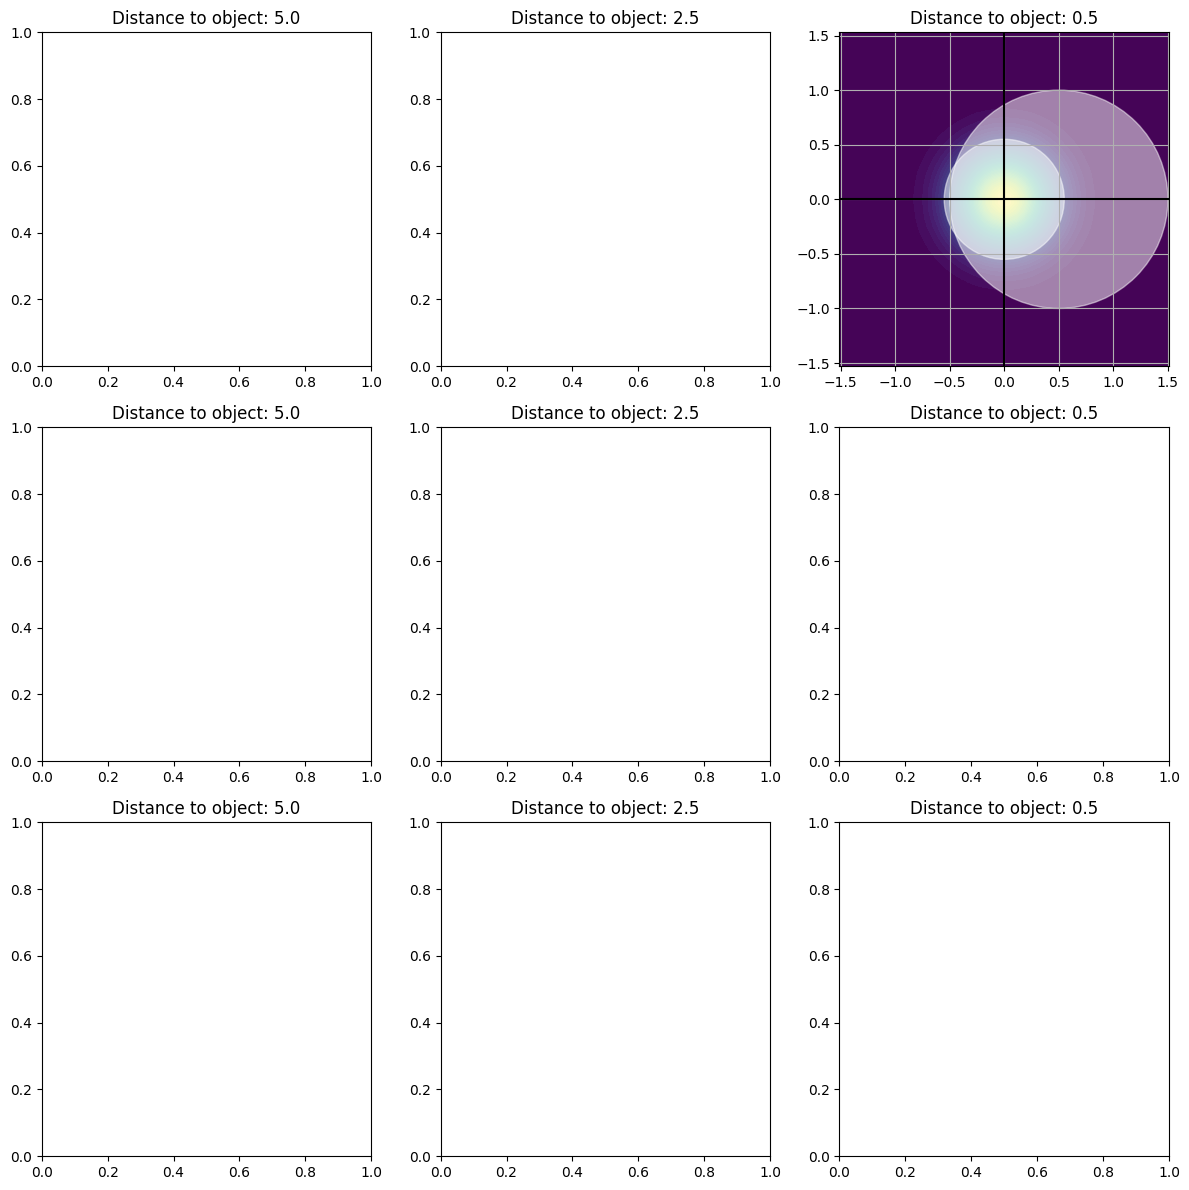

In [90]:
import matplotlib.patches as patches
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 12))

i = 1
for obs_rad in [1, 3, 5]:
    for c_x in [5, 2.5, 0.5]:
        plt.subplot(3, 3, i)
        i += 1

        plt.title(f"Distance to object: {c_x:.1f}")

        if obs_rad != 1 or c_x != 0.5:
            continue

        R = obs_rad

        # Color according to Gaussian.
        square_size = c_x + R + 3
        gaussian_xx, gaussian_yy = np.meshgrid(
            np.linspace(-square_size, square_size, 128),
            np.linspace(-square_size, square_size, 128),
        )
        sigma = 0.3
        gaussian_probability = (
            1
            / (2 * np.pi * sigma**2)
            * np.exp(-0.5 * (gaussian_xx**2 + gaussian_yy**2) / sigma**2)
        )
        plt.contourf(gaussian_xx, gaussian_yy, gaussian_probability, levels=50)

        plt.gca().axvline(x=0, color="k")
        plt.gca().axhline(y=0, color="k")
        plt.grid()
        plt.gca().add_patch(patches.Circle((c_x, 0), R, fill=True, color="white", alpha=0.5))
        plt.gca().add_patch(patches.Circle((0, 0), 0.55, fill=True, color="white", alpha=0.5))

        displacement_direction = compute_agent_obstacle_score(0, 0, c_x, 0, R, sigma)

        print(c_x, R, displacement_direction)

        plt.quiver(
            0, 0, displacement_direction[0], displacement_direction[1], color="red", scale=5
        )
        plt.axis("equal")

        plt.xlim(-square_size + 3, square_size - 3)
        plt.ylim(-square_size + 3, square_size - 3)

plt.tight_layout()
plt.show()